In [ ]:
!pip install xgboost joblib numpy

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

NUM_WOUNDS = 500
DAYS = 14

data = []

for w in range(NUM_WOUNDS):
    wound_id = f"W{w:03d}"


    base_pH = np.random.uniform(5.6, 6.4)
    base_temp = np.random.uniform(36.5, 37.2)
    base_moisture = np.random.uniform(65, 80)

    infection = np.random.rand() < 0.3

    for day in range(1, DAYS + 1):
        time_factor = day / DAYS


        if infection:
            pH = base_pH + np.random.uniform(0.6, 1.2) * time_factor
            temp = base_temp + np.random.uniform(1.2, 2.0) * time_factor
            moisture = base_moisture - np.random.uniform(15, 30) * time_factor
        else:
            pH = base_pH - 0.1 * time_factor
            temp = base_temp - 0.2 * time_factor
            moisture = base_moisture - 5 * time_factor


        pH += np.random.normal(0, 0.03)
        temp += np.random.normal(0, 0.15)
        moisture += np.random.normal(0, 1)


        pH = np.clip(pH, 4.5, 9.0)
        temp = np.clip(temp, 35.0, 40.0)
        moisture = np.clip(moisture, 10.0, 100.0)


        infection_risk = (
            (pH - 5.5) * 30 +
            (temp - 36.5) * 35 +
            (80 - moisture) * 0.7
        )
        infection_risk = np.clip(infection_risk + np.random.normal(0, 5), 0, 100)


        if infection:
            base_healing = 10 + 50 * time_factor
        else:
            base_healing = 5 + 85 * time_factor


        penalty = (
            abs(pH - 6.0) * 20 +
            abs(temp - 37.0) * 20 +
            abs(moisture - 70) * 0.3
        )

        healing_status = base_healing - penalty
        healing_status += np.random.normal(0, 3)
        healing_status = np.clip(healing_status, 0, 100)

        data.append([
            wound_id, day, pH, temp, moisture,
            int(infection_risk), int(healing_status)
        ])

df = pd.DataFrame(
    data,
    columns=[
        "wound_id", "day", "pH", "temperature", "moisture",
        "infection_risk_percent", "healing_status_percent"
    ]
)

df.to_csv("synthetic_wound_data_better_healing.csv", index=False)

df.head(10)


,wound_id,day,pH,temperature,moisture,infection_risk_percent,healing_status_percent
0,W000,1,5.885465,37.116094,77.201979,38,2
1,W000,2,5.901623,37.067416,74.799894,36,6
2,W000,3,5.826456,37.038300,73.895649,34,15
3,W000,4,5.828692,37.328204,74.325561,43,13
4,W000,5,5.847586,37.110710,73.043201,38,27
5,W000,6,5.848024,36.989530,75.689330,30,33
6,W000,7,5.874308,36.882373,73.688773,19,37
7,W000,8,5.848395,37.161984,73.294135,37,45
8,W000,9,5.790991,36.928952,72.304985,34,54
9,W000,10,5.775312,37.071255,72.023398,30,61


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import joblib

features = [
    "day",
    "pH", "temperature", "moisture",
    "pH_lag1", "temperature_lag1", "moisture_lag1"
]

X = df[features]


y_infection = df["infection_risk_percent"]
y_healing = df["healing_status_percent"]

X_train, X_test, y_inf_train, y_inf_test = train_test_split(
    X, y_infection, test_size=0.2, random_state=42
)

_, _, y_heal_train, y_heal_test = train_test_split(
    X, y_healing, test_size=0.2, random_state=42
)

infection_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8
)

healing_model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8
)

infection_model.fit(X_train, y_inf_train)
healing_model.fit(X_train, y_heal_train)

print("Infection MAE:", mean_absolute_error(y_inf_test, infection_model.predict(X_test)))
print("Healing MAE:", mean_absolute_error(y_heal_test, healing_model.predict(X_test)))

joblib.dump(infection_model, "infection_model.pkl")
joblib.dump(healing_model, "healing_model.pkl")


Infection MAE: 3.6543734073638916
Healing MAE: 4.132367134094238


['healing_model.pkl']

In [ ]:
df = df.sort_values(["wound_id", "day"])

for col in ["pH", "temperature", "moisture"]:
    df[f"{col}_lag1"] = df.groupby("wound_id")[col].shift(1)

df = df.dropna()


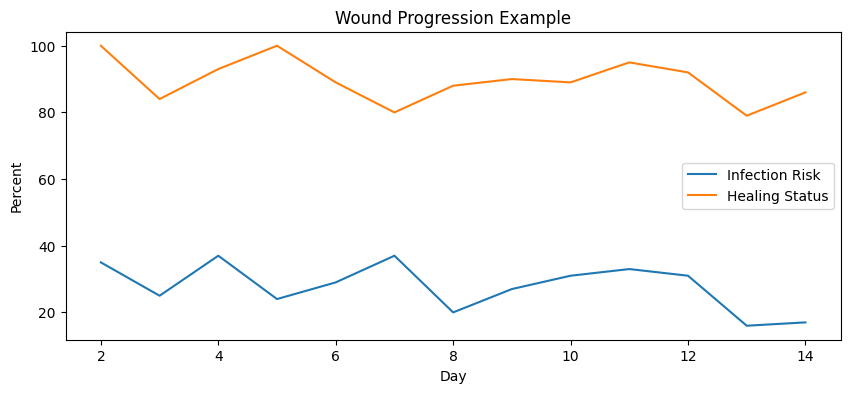

In [ ]:
import matplotlib.pyplot as plt

sample = df[df["wound_id"] == "W010"]

plt.figure(figsize=(10,4))
plt.plot(sample["day"], sample["infection_risk_percent"], label="Infection Risk")
plt.plot(sample["day"], sample["healing_status_percent"], label="Healing Status")
plt.xlabel("Day")
plt.ylabel("Percent")
plt.legend()
plt.title("Wound Progression Example")
plt.show()
